# Imports 

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

# Dataset

In [5]:
fake = pd.read_csv("fake.csv")
true = pd.read_csv("true.csv")

fake["label"] = "fake"
true["label"] = "true"

df = pd.concat([fake, true]).reset_index(drop=True)

# EDA

## Basic Sanity Check

In [8]:
# Shape of the data
df.shape

(44898, 5)

In [9]:
# Columns name
df.columns

Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')

In [10]:
# Datatype of columns
df.dtypes

title      object
text       object
subject    object
date       object
label      object
dtype: object

In [11]:
df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",fake
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",fake
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",fake
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",fake
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",fake


## Missing Values Analysis

In [13]:
df.notnull().count()

title      44898
text       44898
subject    44898
date       44898
label      44898
dtype: int64

There is no missing values in dataset in each columns

## Duplicate Value Check

In [16]:
df.duplicated(subset=['title', 'text']).sum()

5793

In [17]:
# Delete duplicates
print("Before:", df.shape)

df.drop_duplicates(subset=['title', 'text'], inplace=True)

print("After:", df.shape)


Before: (44898, 5)
After: (39105, 5)


## Label Distribution

In [19]:
print("Fake News Count-\n", (df["label"] == "fake").sum())

Fake News Count-
 17908


In [20]:
print("True News Count-\n", (df["label"] == "true").sum())

True News Count-
 21197


In [21]:
df["label"].value_counts(normalize=True) * 100

label
true    54.205345
fake    45.794655
Name: proportion, dtype: float64

This dataset is roughly balanced, which is good. No need for SMOTE, class weights, etc.

## Subject/category distribution
- 'subject' is the category or section the news article claims to belong to. It’s metadata about the article’s topic or source grouping.

In [24]:
# Total count of subject
df["subject"].nunique()

7

In [25]:
# Count how many articles per subject
df.groupby(["subject"]).size()

subject
Government News      532
News                9050
US_News              783
left-news            705
politics            6838
politicsNews       11217
worldnews           9980
dtype: int64

In [26]:
df.groupby(["subject", "label"]).size().unstack(fill_value=0)

label,fake,true
subject,,
Government News,532,0
News,9050,0
US_News,783,0
left-news,705,0
politics,6838,0
politicsNews,0,11217
worldnews,0,9980


Only 'politicsNews' and 'worldnews' belong to true news, others are fake”

This implies:

- 'subject' perfectly predicts the label
- The dataset is structurally biased
- Any model using subject is invalid for real-world use

This is not a small issue. This is textbook data leakage.

## Time Date Analysis

In [29]:
df['date'].head()

0    December 31, 2017
1    December 31, 2017
2    December 30, 2017
3    December 29, 2017
4    December 25, 2017
Name: date, dtype: object

In [30]:
df['date'].astype(str).str[:50].value_counts().head(10)

date
December 6, 2017       166
November 30, 2017      160
November 9, 2017       157
October 13, 2017       153
September 21, 2017     153
September 6, 2017      151
September 7, 2017      148
September 22, 2017     146
October 19, 2017       144
October 18, 2017       142
Name: count, dtype: int64

In [31]:
# type conversion
df['date'] = pd.to_datetime(df['date'], format='mixed', dayfirst=True, errors='coerce')

In [32]:
df.dtypes

title              object
text               object
subject            object
date       datetime64[ns]
label              object
dtype: object

In [33]:
df[df['date'].isna()]

,title,text,subject,date,label
9358,https://100percentfedup.com/served-roy-moore-v...,https://100percentfedup.com/served-roy-moore-v...,politics,NaT,fake
15507,https://100percentfedup.com/video-hillary-aske...,https://100percentfedup.com/video-hillary-aske...,politics,NaT,fake
15508,https://100percentfedup.com/12-yr-old-black-co...,https://100percentfedup.com/12-yr-old-black-co...,politics,NaT,fake
15839,https://fedup.wpengine.com/wp-content/uploads/...,https://fedup.wpengine.com/wp-content/uploads/...,politics,NaT,fake
15840,https://fedup.wpengine.com/wp-content/uploads/...,https://fedup.wpengine.com/wp-content/uploads/...,politics,NaT,fake
18933,Homepage,[vc_row][vc_column width= 1/1 ][td_block_trend...,left-news,NaT,fake


In [34]:
df = df[df['date'].notna()]

In [35]:
df['year_month'] = df['date'].dt.to_period('M')

In [36]:
df['year_month'].head()

0    2017-12
1    2017-12
2    2017-12
3    2017-12
4    2017-12
Name: year_month, dtype: period[M]

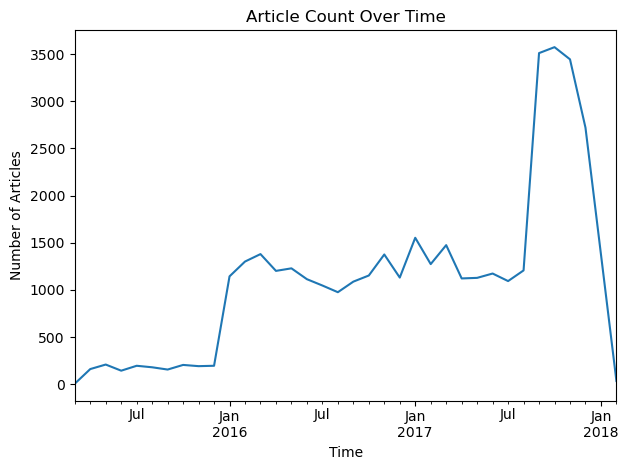

In [37]:
article_counts = df.groupby('year_month').size()

article_counts.plot(kind='line')
plt.xlabel('Time')
plt.ylabel('Number of Articles')
plt.title('Article Count Over Time')
plt.tight_layout()
plt.show()

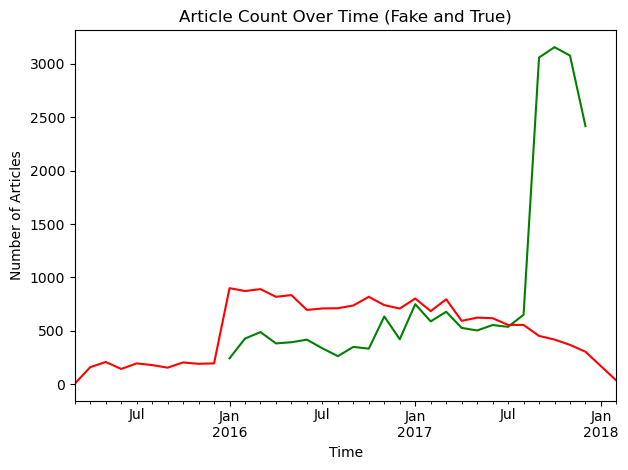

In [38]:
article_counts_true = df[df['label'] == 'true'].groupby('year_month').size()
article_counts_fake = df[df['label'] == 'fake'].groupby('year_month').size()

article_counts_true.plot(kind='line', color='green')
article_counts_fake.plot(kind='line', color='red')

plt.xlabel('Time')
plt.ylabel('Number of Articles')
plt.title('Article Count Over Time (Fake and True)')
plt.tight_layout()
plt.show()

### Rolling Average

A rolling average (or moving average) graph smooths out short-term fluctuations in data—such as volatile daily sales or stock prices—by plotting the average of a specific, shifting window of data points (e.g., a 7-day or 12-month average). 

This technique reduces noise, highlights long-term trends, and reveals patterns that are difficult to spot in raw data. 

In [40]:
# rolling avg
monthly_counts = (
    df
    .groupby([df['date'].dt.to_period('M'), 'label'])
    .size()
    .unstack(fill_value=0)
)

monthly_counts.index = monthly_counts.index.to_timestamp()

In [41]:
rolling_3m = monthly_counts.rolling(window=3).mean()

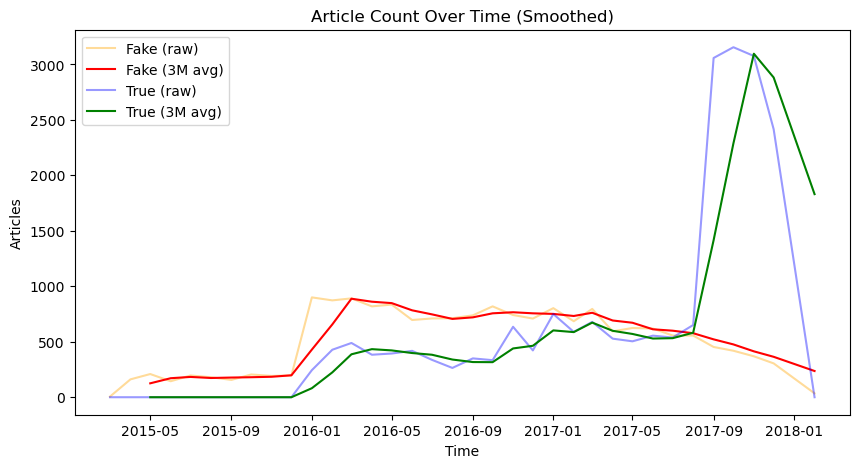

In [42]:
plt.figure(figsize=(10,5))

plt.plot(monthly_counts.index, monthly_counts['fake'], alpha=0.4, label='Fake (raw)', color='orange')
plt.plot(monthly_counts.index, rolling_3m['fake'], label='Fake (3M avg)', color='red')

plt.plot(monthly_counts.index, monthly_counts['true'], alpha=0.4, label='True (raw)', color='blue')
plt.plot(monthly_counts.index, rolling_3m['true'], label='True (3M avg)', color='green')

plt.legend()
plt.title('Article Count Over Time (Smoothed)')
plt.ylabel('Articles')
plt.xlabel('Time')
plt.show()

If model sees:

- mostly fake articles in 2015–2016
- mostly true articles in late-2017

Then the model doesn’t need language.
It just needs time-correlated features.

Even subtle ones:
- writing style drift
- topic drift
- publication patterns

That’s leakage.

## Text Length Analysis

In [45]:
# Number of characters
df['char_count'] = df['text'].apply(len)

# Number of words
df['word_count'] = df['text'].apply(lambda x: len(x.split()))


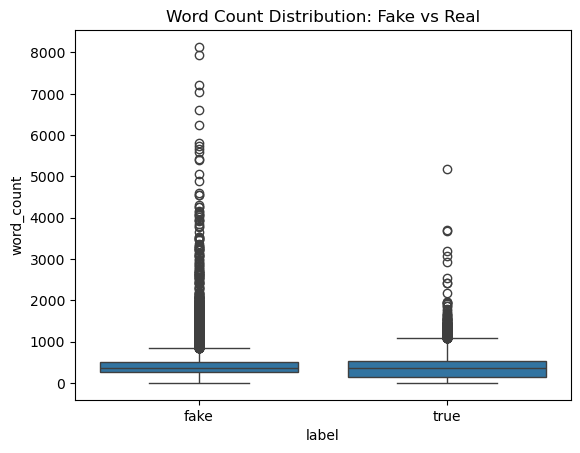

In [46]:
# Boxplot for word count
sns.boxplot(x='label', y='word_count', data=df)
plt.title('Word Count Distribution: Fake vs Real')
plt.show()

- **Median almost identical -** Typical article lengths are basically the same. So any claim like “fake news is shorter” → not supported.
- **Mean higher for fake -** Because fake has **extreme long outliers** (max 8135).
- **Fake has heavier tail -** Some fake articles are extremely long (possibly copy-paste, rambling, propaganda dumps)

Word count alone does not clearly separate fake and real news. However, fake news exhibits greater variability and more extreme long-form outliers.

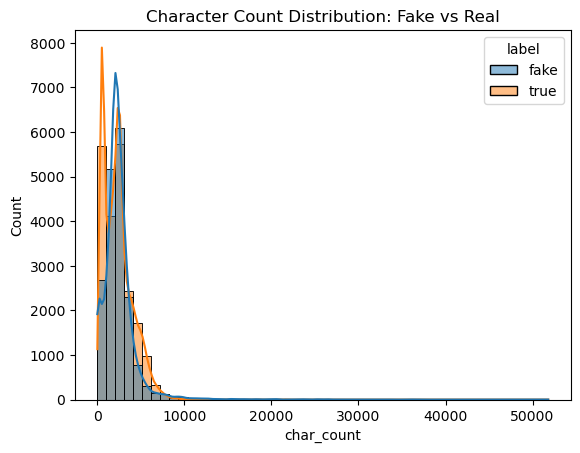

In [48]:
# Histogram for char count
sns.histplot(data=df, x='char_count', hue='label', kde=True, bins=50)
plt.title('Character Count Distribution: Fake vs Real')
plt.show()

- Both distributions heavily right-skewed
- Large overlap
- Fake slightly more spread

Character count distribution shows strong overlap between classes, reinforcing that length-based features alone are weak discriminators.

In [50]:
# Log-transform word counts
df['log_word_count'] = np.log1p(df['word_count'])

# Log-transform character counts
df['log_char_count'] = np.log1p(df['char_count'])

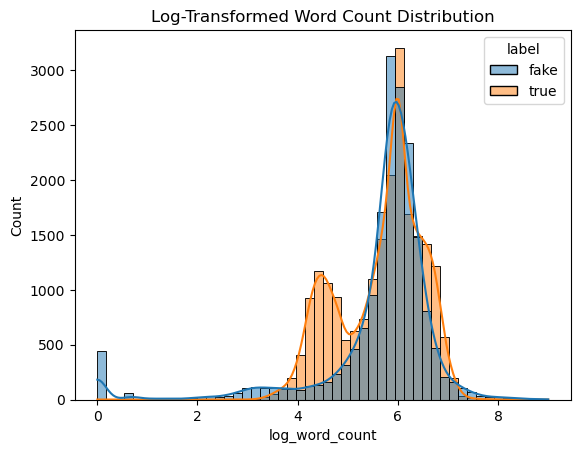

In [51]:
sns.histplot(data=df, x='log_word_count', hue='label', kde=True, bins=50)
plt.title('Log-Transformed Word Count Distribution')
plt.show()

**→** After log transformation, real news articles show a more concentrated distribution, while fake news articles remain more dispersed, indicating higher variability in article length.

In [53]:
bins = [0, 50, 100, 200, 500, 1000, 5000]
labels = ['very short', 'short', 'medium', 'long', 'very long', 'extremely long']
df['length_category'] = pd.cut(df['word_count'], bins=bins, labels=labels)

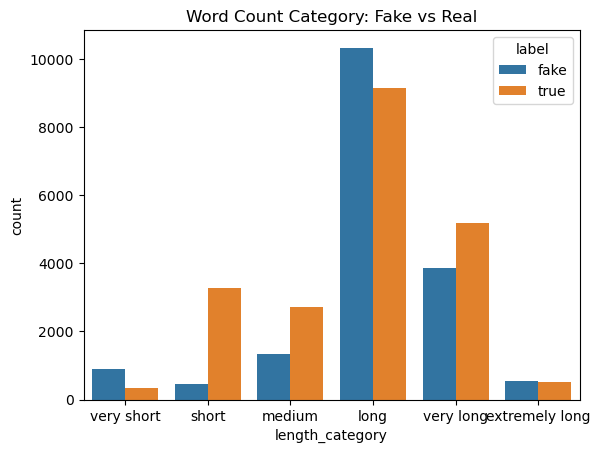

In [54]:
sns.countplot(
    data=df,
    x='length_category',
    hue='label'
)
plt.title('Word Count Category: Fake vs Real')
plt.show()

In [55]:
df[df['length_category'] == 'very short'].head()

,title,text,subject,date,label,year_month,char_count,word_count,log_word_count,log_char_count,length_category
4479,Here’s The Entire Debate Wrapped Up In One PE...,There s not much to say here. GIPHY killed it ...,News,2016-09-26,fake,2016-09,260,36,3.610918,5.564520,very short
10637,WOW! EVEN CNN’s REPORTING On Mueller’s New Rus...,CNN Reports Three members of the legal team ...,politics,2017-06-13,fake,2017-06,278,43,3.784190,5.631212,very short
10735,DELUSIONAL HILLARY Calls Her Email Scandal The...,Hillary Clinton continues on the path to compl...,politics,2017-05-31,fake,2017-05,311,46,3.850148,5.743003,very short
10929,LOU DOBBS: SEAN SPICER On Trump Firing Comey [...,White House Press Secretary Sean Spicer appear...,politics,2017-05-10,fake,2017-05,179,30,3.433987,5.192957,very short
10964,HILARIOUS! Random French People Say They’d Gla...,Watch this hilarious video from our British co...,politics,2017-05-05,fake,2017-05,380,49,3.912023,5.942799,very short


In [56]:
df['text'].loc[4479]

'There s not much to say here. GIPHY killed it with this one: When someone goes on a rant but you have receipts. https://t.co/axe58zCeJL #debatenight #Debates2016 pic.twitter.com/KTgdWAvaAb  GIPHY (@giphy) September 27, 2016Photo by Justin Sullivan/Getty Images'

In [57]:
# Descriptive Statistics Table
df.groupby('label')[['word_count', 'char_count']].describe()

word_count                                                            \
           count        mean         std  min    25%    50%    75%     max   
label                                                                        
fake     17902.0  414.826053  356.969625  0.0  264.0  371.0  499.0  8135.0   
true     21197.0  384.863471  273.831833  0.0  147.0  359.0  523.0  5172.0   

      char_count                                                          \
           count         mean          std  min      25%     50%     75%   
label                                                                      
fake     17902.0  2487.223550  2209.801856  1.0  1573.25  2205.0  2981.0   
true     21197.0  2378.697646  1684.004610  1.0   906.00  2217.0  3227.0   

                
           max  
label           
fake   51794.0  
true   29781.0

- **Std dev:** Fake = 357 / True = 274<br>
 Fake news more variable.

- **75th percentile:** Fake = 500 / True = 523<br>
 Upper typical range similar.

- **Min = 1** for both<br>
 That means: Missing text / Empty strings / Bad rows<br>
 This is a data quality issue.

In [59]:
(df['word_count'] == 1).sum()

56

## Critical Data Issues

**1. Zero-length articles**

In [61]:
# remove article that has 1 word_count in text
df = df[df['word_count'] > 1]

**2. Extreme outliers (8135 words)**

In [63]:
df.sort_values('word_count', ascending=False).head(6)

,title,text,subject,date,label,year_month,char_count,word_count,log_word_count,log_char_count,length_category
22303,MEDIA TRIPWIRE? Ping Pong Pizza Conspiracy Pro...,Funny how secrets travel. I d start to believ...,US_News,2016-12-28,fake,2016-12,51794,8135,9.004054,10.855049,NaN
21978,The Las Vegas Mass Shooting – More to the Stor...,Shawn Helton 21st Century WireAlthough many ar...,US_News,2017-10-12,fake,2017-10,48835,7928,8.978282,10.796223,NaN
22506,"CULT CRIMES, MASS SHOOTINGS & MEDIA MIND CONTR...",Shawn Helton 21st Century WireThe 1994 cult fi...,US_News,2016-08-13,fake,2016-08,44926,7209,8.883224,10.712794,NaN
9731,ANTI-AMERICAN GEORGE SOROS Locks Arms With NFL...,We just discovered another reason NOT to suppo...,politics,2017-10-07,fake,2017-10,49705,7033,8.858511,10.813881,NaN
12406,WOW! AMERICA IS UNDER ATTACK By These 187 Orga...,There have been many articles written about Ge...,politics,2016-11-13,fake,2016-11,46960,6608,8.796188,10.757073,NaN
22013,What is The Deep State?,One of the ancillary benefits of Donald Trump ...,US_News,2017-09-02,fake,2017-09,39414,6253,8.740977,10.581902,NaN


## Title vs text comparision

In [65]:
df['title_word_count'] = np.log1p(df['title'].apply(lambda x: len(x.split())))
df['text_word_count'] = np.log1p(df['text'].apply(lambda x: len(x.split())))

df['title_text_ratio'] = df['title_word_count'] / df['text_word_count']

In [66]:
df[df['title_text_ratio'] > 1].groupby('label').size()

label
fake    169
dtype: int64

In [67]:
df[df['title_text_ratio'] > 1].head(5)

,title,text,subject,date,label,year_month,char_count,word_count,log_word_count,log_char_count,length_category,title_word_count,text_word_count,title_text_ratio
11233,JUDGE JEANINE’S OPENING STATEMENT: “Our Presid...,Watch my #OpeningStatment pic.twitter.com/Qp...,politics,2017-04-01,fake,2017-04,99,10,2.397895,4.605170,very short,2.772589,2.397895,1.156259
11324,HYSTERICAL! HERE’S WHY TRUMP SAID TO REPORTER:...,Read more:WT,politics,2017-03-23,fake,2017-03,12,2,1.098612,2.564949,very short,2.564949,1.098612,2.334718
11389,HYSTERICAL! RAND PAUL FIRES BACK AT JOHN MCCAI...,HERE S WHAT MCCAIN SAID THAT GOT RAND PAUL ALL...,politics,2017-03-16,fake,2017-03,57,12,2.564949,4.060443,very short,2.833213,2.564949,1.104588
11406,RACHEL MADDOW Announces Plan To Reveal Trump’s...,Maddow has a freak out at the 48 second mark:,politics,2017-03-14,fake,2017-03,46,10,2.397895,3.850148,very short,2.890372,2.397895,1.205379
11418,VIRAL VIDEO: UNIV OF WI Students Busted Agreei...,Watch the hypocrisy in action:,politics,2017-03-13,fake,2017-03,30,5,1.791759,3.433987,very short,2.944439,1.791759,1.643323


In [68]:
df = df[~(df['title_text_ratio'] > 1)]
df['label'].value_counts(normalize=True)

label
true    0.551591
fake    0.448409
Name: proportion, dtype: float64

- Articles with extremely short or nonsensical body text were removed to prevent noise contamination and unreliable linguistic signals during feature extraction.
- “Removed rows where title_text_ratio > 1”

In [70]:
df = df[df['word_count'] > 50]
df['label'].value_counts(normalize=True)

label
true    0.557498
fake    0.442502
Name: proportion, dtype: float64

**→** Very short samples (<50 words) were removed after manual inspection revealed that they predominantly contained non-article content such as social media captions, metadata, and scraping noise. These samples lacked sufficient linguistic structure for reliable NLP modeling.

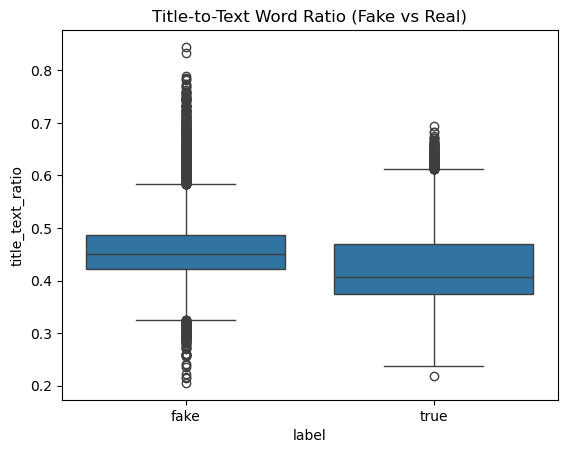

In [72]:
sns.boxplot(x='label', y='title_text_ratio', data=df)
plt.title('Title-to-Text Word Ratio (Fake vs Real)')
plt.show()

What I see conceptually:
- Fake median slightly higher than True
- Heavy overlap between distributions
- Both roughly centered around ~0.4–0.5

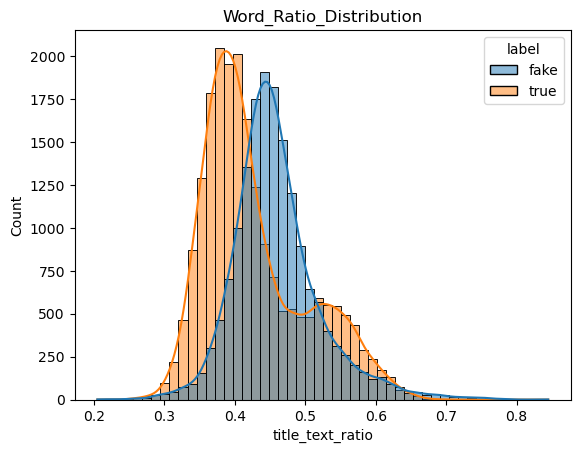

In [74]:
sns.histplot(data=df, x="title_text_ratio", hue="label", kde=True, bins=50)
plt.title("Word_Ratio_Distribution")
plt.show()

- Both bell-shaped-ish
- Fake slightly right-shifted
- True slightly left-shifted
- Overlap ~70–80

**→** Cleanup didn’t distort reality.

In [76]:
# After cleaning, EDA metrics to confirm no unintended distributional shift
df.groupby('label')['word_count'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
fake,16554.0,447.334300,351.780864,51.0,303.0,387.0,512.0,8135.0
true,20856.0,390.485855,272.477539,51.0,161.0,363.0,529.0,5172.0


## Vocabulary Analysis

In [78]:
import re

def basic_clean(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

In [79]:
df['clean_text'] = df['text'].apply(basic_clean)

In [80]:
df['unique_word_count'] = df['clean_text'].apply(lambda x: len(set(x.split())))

In [81]:
df['lexical_diversity'] = df['unique_word_count'] / df['text_word_count']

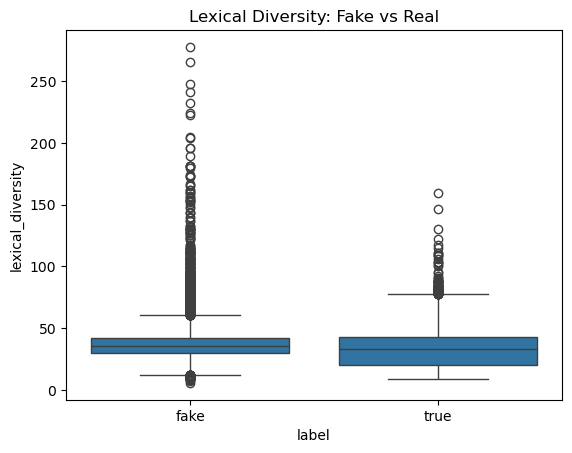

In [82]:
# compare lexical diversity

sns.boxplot(data=df, x='label', y='lexical_diversity')
plt.title('Lexical Diversity: Fake vs Real')
plt.show()

- Fake slightly higher spread
- More extreme outliers in Fake
- Central tendency similar
  
**→** Fake articles may use more varied vocabulary (sensational style)

## N-gram Analysis

In [85]:
fake_text = df[df['label'] == 'fake']['clean_text']
real_text = df[df['label'] == 'true']['clean_text']

In [86]:
from sklearn.feature_extraction.text import CountVectorizer

In [87]:
def top_ngrams(corpus, ngram_range=(2,2), top_k=20):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words='english')
    X = vec.fit_transform(corpus)
    counts = X.sum(axis=0).A1
    ngrams = vec.get_feature_names_out()
    return sorted(zip(ngrams, counts), key=lambda x: x[1], reverse=True)[:top_k]

In [88]:
top_fake_bigrams = top_ngrams(fake_text)
top_real_bigrams = top_ngrams(real_text)

top_fake_bigrams, top_real_bigrams

([('donald trump', 13129),
  ('hillary clinton', 4978),
  ('white house', 4829),
  ('united states', 4591),
  ('president obama', 3219),
  ('new york', 3036),
  ('fox news', 2477),
  ('president trump', 2404),
  ('trump realdonaldtrump', 1520),
  ('trump campaign', 1512),
  ('barack obama', 1473),
  ('supreme court', 1405),
  ('screen capture', 1318),
  ('republican party', 1297),
  ('featured image', 1258),
  ('ted cruz', 1257),
  ('fake news', 1244),
  ('trump said', 1199),
  ('american people', 1145),
  ('st century', 1136)],
 [('united states', 11979),
  ('white house', 8148),
  ('donald trump', 7886),
  ('washington reuters', 6352),
  ('president donald', 5823),
  ('north korea', 5112),
  ('new york', 4305),
  ('prime minister', 4038),
  ('said statement', 3881),
  ('trump said', 3520),
  ('told reuters', 3439),
  ('islamic state', 3314),
  ('told reporters', 3113),
  ('president barack', 2874),
  ('barack obama', 2353),
  ('supreme court', 2327),
  ('house representatives', 2233)

In [89]:
df_fake_ngrams = pd.DataFrame(top_fake_bigrams, columns=['ngram', 'count'])

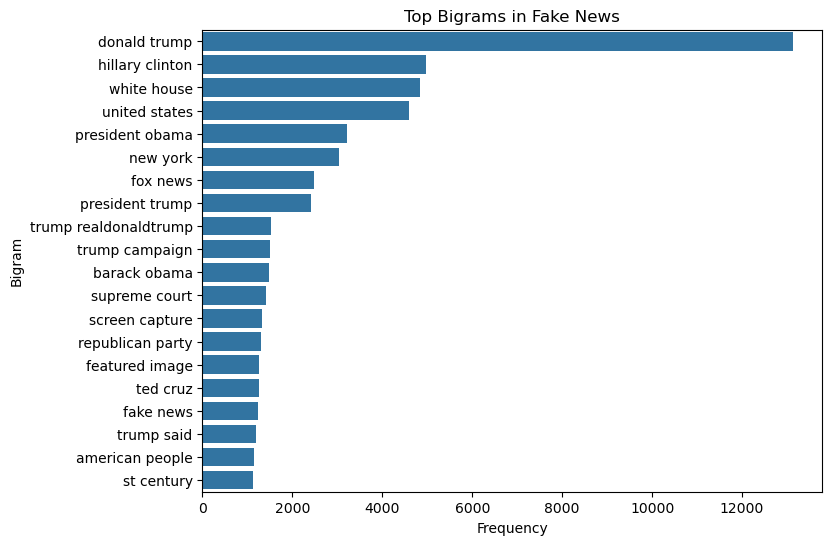

In [90]:
plt.figure(figsize=(8, 6))
sns.barplot(
    x='count',
    y='ngram',
    data=df_fake_ngrams
)
plt.title('Top Bigrams in Fake News')
plt.xlabel('Frequency')
plt.ylabel('Bigram')
plt.show()

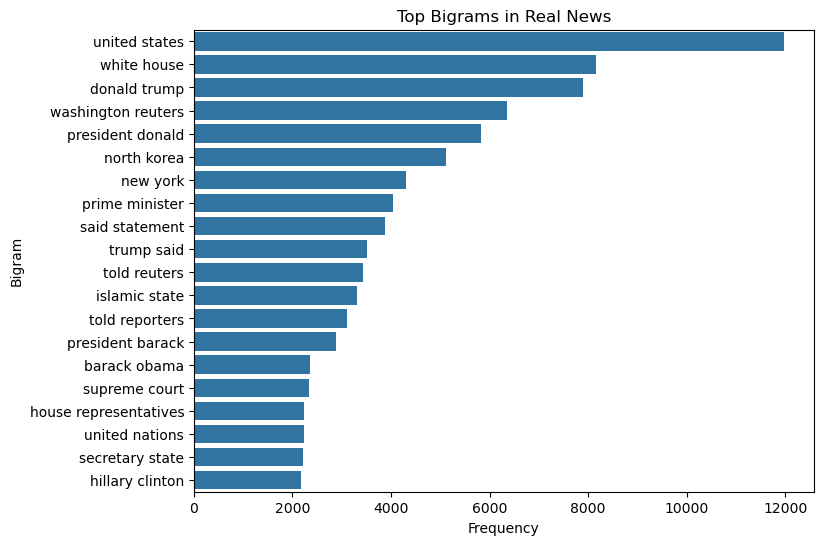

In [91]:
df_real_ngrams = pd.DataFrame(top_real_bigrams, columns=['ngram', 'count'])

plt.figure(figsize=(8, 6))
sns.barplot(
    x='count',
    y='ngram',
    data=df_real_ngrams
)
plt.title('Top Bigrams in Real News')
plt.xlabel('Frequency')
plt.ylabel('Bigram')
plt.show()

# Rank features

## Significance Test (Fake vs True)

**Mann–Whitney U Test -** It’s a non-parametric statistical test used to compare two independent groups. <br>
                 **It answers:** Are the values in these two groups distributed differently?

- Group 1 = fake news
- Group 2 = true news
- Feature = word_count / lexical_diversity / etc.
  <br>

  

In [93]:
num_cols = ['char_count', 'word_count','title_word_count', 'text_word_count', 'title_text_ratio', 'unique_word_count', 'lexical_diversity']

In [94]:
df[num_cols].describe()

,char_count,word_count,title_word_count,text_word_count,title_text_ratio,unique_word_count,lexical_diversity
count,37410.000000,37410.000000,37410.000000,37410.000000,37410.000000,37410.000000,37410.000000
mean,2532.145362,415.641406,2.521833,5.803962,0.441246,214.768992,35.260129
std,1922.714575,311.359859,0.256331,0.714274,0.070754,119.937698,15.406553
min,265.000000,51.000000,1.386294,3.951244,0.204984,23.000000,5.664407
25%,1445.250000,238.000000,2.302585,5.476464,0.390457,142.000000,25.831686
50%,2275.000000,376.000000,2.484907,5.932245,0.431019,205.000000,34.637186
75%,3143.000000,518.000000,2.708050,6.251904,0.480919,266.000000,42.584145
max,51794.000000,8135.000000,3.761200,9.004054,0.844761,2468.000000,277.827052


In [95]:
def mwu_test(fake, true):
    stat, p = mannwhitneyu(fake, true, alternative='two-sided')
    return round(p, 3)
    
MWU_results = []

for col in num_cols:
    fake = df[df['label'] == 'fake'][col]
    true = df[df['label'] == 'true'][col]
    p = mwu_test(fake, true)
    MWU_results.append(p)

In [96]:
def cohens_d(a, b):
    return (np.mean(a) - np.mean(b)) / np.sqrt(
        (np.std(a, ddof=1)**2 + np.std(b, ddof=1)**2) / 2
    )

Cohens_d_res = []
Interpretation = []
for col in num_cols:
    fake = df[df['label'] == 'fake'][col]
    true = df[df['label'] == 'true'][col]
    d = cohens_d(fake, true)
    if d < 0.2:
        i = "Tiny"
    elif d < 0.4:
        i = "Small"
    elif d < 0.8:
        i = "Medium"
    elif d < 1.2:
        i = "Large"
    else:
        i = "Very Large"
    Cohens_d_res.append(round(d, 3))
    Interpretation.append(i)

In [97]:
s = {
    "Feature": num_cols,
    "p-value": MWU_results,
    "Cohen’s d": Cohens_d_res,
    "Interpretation": Interpretation
}

In [98]:
res = pd.DataFrame(s)
res

,Feature,p-value,Cohen’s d,Interpretation
0,char_count,0.0,0.138,Tiny
1,word_count,0.0,0.181,Tiny
2,title_word_count,0.0,1.541,Very Large
3,text_word_count,0.0,0.354,Small
4,title_text_ratio,0.0,0.456,Medium
5,unique_word_count,0.0,0.223,Small
6,lexical_diversity,0.0,0.250,Small


Dataset size = 37,410 rows

With large samples:
- Even tiny deviations → statistically significant
- Normality tests become hypersensitive
- Almost always p ≈ 0  <br>


Even mildly skewed real-world data → fails.

<Axes: xlabel='text_word_count', ylabel='Density'>

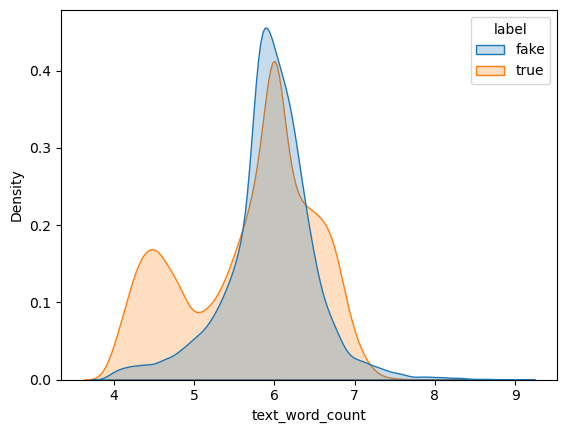

In [100]:
sns.kdeplot(data=df, x='text_word_count', hue='label', fill=True)

**title_word_count (d = 1.54 → Very Large Effect)**

- Strong separation between fake vs true
- Distributions show noticeable shift <br>

→ Fake news titles differ substantially in length compared to true news.

<Axes: xlabel='title_text_ratio', ylabel='Density'>

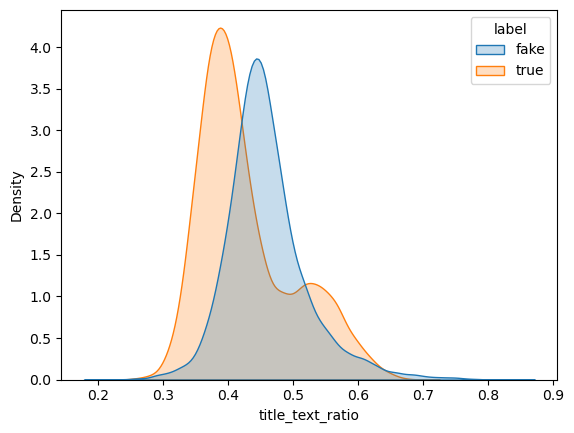

In [102]:
sns.kdeplot(data=df, x='title_text_ratio', hue='label', fill=True)

**title_text_ratio (d = 0.46 → Medium Effect)**

- Moderate separation
- KDE plot shows class shift with overlap  <br>

→ Fake and true articles differ in the balance between title length and body length.

In [104]:
new_df = df[['title', 'text', 'date', 'label', 'title_word_count', 'title_text_ratio']]

In [105]:
new_df.to_csv("news_cleaned.csv", index=False)

# Conclusion

This exploratory data analysis was conducted to understand the structure, quality, and characteristics of the Fake News dataset before model development.

**Dataset Structure**
- The dataset contains the key fields: title, text, date, and label.
- Additional engineered features such as title_word_count, text_word_count, and title_text_ratio were created to capture linguistic patterns.

**Data Quality Checks**
- Missing values were identified and handled appropriately.
- Date column was converted to proper datetime format.
- No critical structural inconsistencies were observed after cleaning.

**Text Characteristics**
- Articles show large variance in length.
- Fake and real news differ in word count distributions.
- Title-to-text ratio reveals stylistic differences, potentially useful for classification.

**Feature Observations**
- Word count features exhibited scale mismatch, indicating the need for normalization/standardization during preprocessing.
- Engineered numerical features appear informative but require proper scaling.

**Temporal Analysis**
- News articles span across multiple dates.
- Using date-based splitting is justified to prevent data leakage and simulate real-world prediction scenarios.

**Key Insights**

1. Text length and structure vary significantly between classes.
2. Engineered features may enhance model performance.
3. Proper preprocessing (scaling + vectorization) is essential.
4. Time-aware train-test split is recommended.